In [1]:
import rasterio
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

In [3]:
month = '8'
with rasterio.open(f"/Users/cherryleheu/Documents/HCDP/Data/climo/monthly/rainfall/monthly_rainfall_clim_statewide_1991-2020_{month}.tif") as src:
    rf_climo = src.read(1)
    nodata_climo = src.nodata
    meta = src.meta.copy()

masked_climo = np.ma.masked_equal(rf_climo, nodata_climo)

with rasterio.open(f"../public/tifs/rainfall_2025_0{month}.tif") as src:
    rf = src.read(1)
    nodata_rf = src.nodata
    transform = src.transform

masked_rf = np.ma.masked_equal(rf, nodata_rf)

pdiff = (masked_rf - masked_climo) / masked_climo * 100

combined_mask = np.ma.getmask(masked_rf) | np.ma.getmask(masked_climo)
pdiff_masked = np.ma.array(pdiff, mask=combined_mask)

out_nodata = -9999 
meta.update(
    dtype="float32",
    nodata=out_nodata
)

with rasterio.open(f"../public/tifs/pdiff_2025_0{month}.tif", "w", **meta) as dst:
    dst.write(pdiff_masked.filled(out_nodata).astype("float32"), 1)


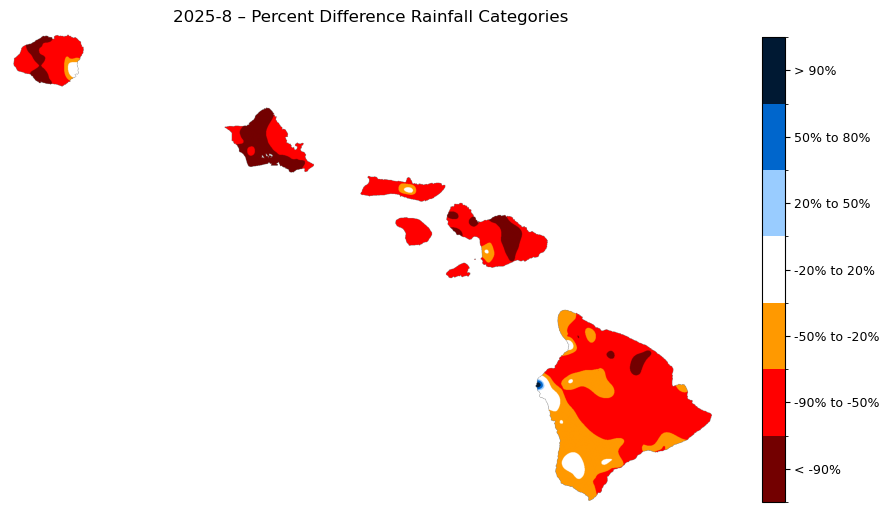

In [5]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

thresholds = [
    (-np.inf, -80, "#730000", "< -90%"),
    (-80, -50, "#FF0000", "-90% to -50%"),
    (-50, -30, "#FF9900", "-50% to -20%"),
    (-30, 30, "#FFFFFF", "-20% to 20%"),
    (30, 50, "#99CCFF", "20% to 50%"),
    (50, 80, "#0066CC", "50% to 80%"),
    (80, np.inf, "#001933", "> 90%"),
]

with rasterio.open(f"../public/tifs/pdiff_2025_0{month}.tif") as src:
    data = src.read(1)
    profile = src.profile
    nodata = src.nodata

data = np.where(data == nodata, np.nan, data)
categorical = np.full_like(data, 255, dtype=np.uint8)

for i, (low, high, _, _) in enumerate(thresholds):
    mask = (data > low) & (data <= high)
    categorical[mask] = i

profile.update(dtype=rasterio.uint8, count=1, compress='lzw', nodata=255)
with rasterio.open(f"../public/tifs/rf_pdiff_cat_0{month}.tif", "w", **profile) as dst:
    dst.write(categorical, 1)

colors = [c for _, _, c, _ in thresholds]
labels = [l for _, _, _, l in thresholds]
cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(-0.5, len(colors) + 0.5), len(colors))

plt.figure(figsize=(9, 6))
categorical_masked = np.ma.masked_where(categorical == 255, categorical)

im = plt.imshow(categorical_masked, cmap=cmap, norm=norm)
plt.axis("off")

cbar = plt.colorbar(im, fraction=0.03, pad=0.04)
cbar.set_ticks(range(len(colors)))
cbar.set_ticklabels(labels)
cbar.ax.tick_params(labelsize=9)
plt.title(f"2025-{month} – Percent Difference Rainfall Categories")
plt.tight_layout()
plt.show()


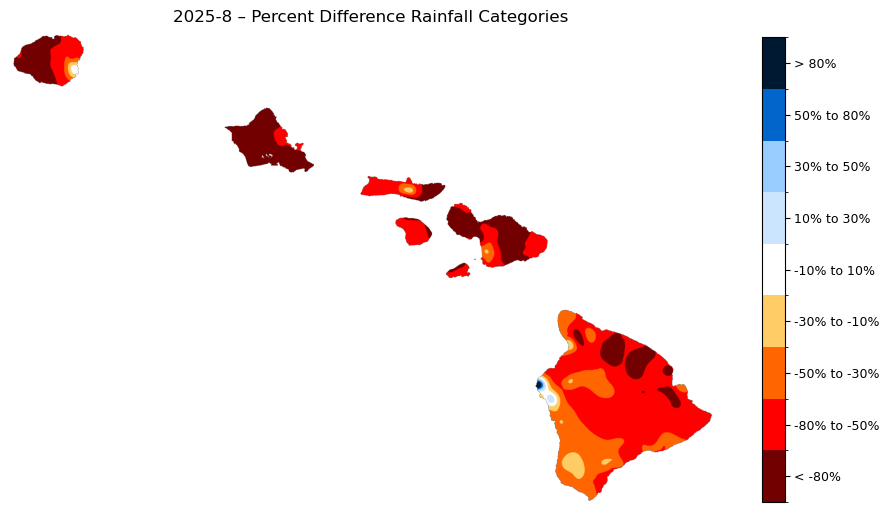

In [9]:
thresholds = [
    (-np.inf, -70, "#730000", "< -80%"),
    (-70, -50, "#FF0000", "-80% to -50%"),
    (-50, -30, "#FF6600", "-50% to -30%"),
    (-30, -10, "#FFCC66", "-30% to -10%"),
    (-10, 10,  "#FFFFFF", "-10% to 10%"),
    (10, 30,  "#CCE5FF", "10% to 30%"),
    (30, 50,  "#99CCFF", "30% to 50%"),
    (50, 70,  "#0066CC", "50% to 80%"),
    (70, np.inf, "#001933", "> 80%"),
]




with rasterio.open(f"../public/tifs/pdiff_2025_0{month}.tif") as src:
    data = src.read(1)
    profile = src.profile
    nodata = src.nodata

data = np.where(data == nodata, np.nan, data)
categorical = np.full_like(data, 255, dtype=np.uint8)

for i, (low, high, _, _) in enumerate(thresholds):
    mask = (data > low) & (data <= high)
    categorical[mask] = i

profile.update(dtype=rasterio.uint8, count=1, compress='lzw', nodata=255)
with rasterio.open(f"../public/tifs/rf_pdiff_cat_0{month}.tif", "w", **profile) as dst:
    dst.write(categorical, 1)

colors = [c for _, _, c, _ in thresholds]
labels = [l for _, _, _, l in thresholds]
cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(-0.5, len(colors) + 0.5), len(colors))

plt.figure(figsize=(9, 6))
categorical_masked = np.ma.masked_where(categorical == 255, categorical)

im = plt.imshow(categorical_masked, cmap=cmap, norm=norm)
plt.axis("off")

cbar = plt.colorbar(im, fraction=0.03, pad=0.04)
cbar.set_ticks(range(len(colors)))
cbar.set_ticklabels(labels)
cbar.ax.tick_params(labelsize=9)
plt.title(f"2025-{month} – Percent Difference Rainfall Categories")
plt.tight_layout()
plt.show()


/var/folders/vl/70ggslts0x98b_vgphfybj140000gn/T/ipykernel_20711/3695535881.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viridis_r = plt.cm.get_cmap("viridis_r", len(thresholds))


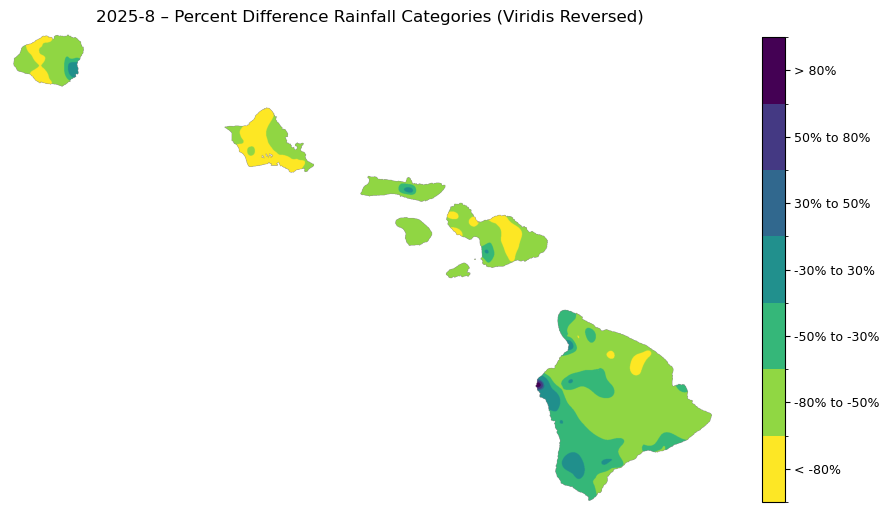

In [ ]:
thresholds = [
    (-np.inf, -80, "< -80%"),
    (-80, -50, "-80% to -50%"),
    (-50, -30, "-50% to -30%"),
    (-30, 30, "-30% to 30%"),
    (30, 50, "30% to 50%"),
    (50, 80, "50% to 80%"),
    (80, np.inf, "> 80%"),
]

with rasterio.open(f"../public/tifs/pdiff_2025_0{month}.tif") as src:
    data = src.read(1)
    profile = src.profile
    nodata = src.nodata

data = np.where(data == nodata, np.nan, data)
categorical = np.full_like(data, 255, dtype=np.uint8)

for i, (low, high, _) in enumerate(thresholds):
    mask = (data > low) & (data <= high)
    categorical[mask] = i

profile.update(dtype=rasterio.uint8, count=1, compress='lzw', nodata=255)
with rasterio.open(f"../public/tifs/rf_pdiff_cat_0{month}.tif", "w", **profile) as dst:
    dst.write(categorical, 1)

viridis_r = plt.cm.get_cmap("viridis_r", len(thresholds))
colors = [viridis_r(i) for i in range(len(thresholds))]
labels = [l for _, _, l in thresholds]

cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(-0.5, len(colors) + 0.5), len(colors))

plt.figure(figsize=(9, 6))
categorical_masked = np.ma.masked_where(categorical == 255, categorical)

im = plt.imshow(categorical_masked, cmap=cmap, norm=norm)
plt.axis("off")

cbar = plt.colorbar(im, fraction=0.03, pad=0.04)
cbar.set_ticks(range(len(colors)))
cbar.set_ticklabels(labels)
cbar.ax.tick_params(labelsize=9)
plt.title(f"2025-{month} – Percent Difference Rainfall Categories (Viridis Reversed)")
plt.tight_layout()
plt.show()


In [2]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

thresholds = [
    (-np.inf, -70, "#4a0000", "< -70%"),
    (-70, -50, "#a50000", "-70% to -50%"),
    (-50, -30, "#ff3333", "-50% to -30%"),
    (-30, -10, "#ffb366", "-30% to -10%"),
    (-10, 10,  "#ffffff", "-10% to 10%"),
    (10, 30,  "#a3c9ff", "10% to 30%"),
    (30, 50,  "#3385ff", "30% to 50%"),
    (50, 70,  "#0040a8", "50% to 70%"),
    (70, np.inf, "#001933", "> 70%"),
]

with rasterio.open(f"../public/tifs/pdiff_2025_0{month}.tif") as src:
    data = src.read(1)
    profile = src.profile
    nodata = src.nodata

data = np.where(data == nodata, np.nan, data)
categorical = np.full_like(data, 255, dtype=np.uint8)

for i, (low, high, _) in enumerate(thresholds):
    mask = (data > low) & (data <= high)
    categorical[mask] = i

profile.update(dtype=rasterio.uint8, count=1, compress='lzw', nodata=255)
with rasterio.open(f"../public/tifs/rf_pdiff_cat_0{month}.tif", "w", **profile) as dst:
    dst.write(categorical, 1)

# --- Diverging colormap: dry = red, wet = blue ---
cmap_base = plt.cm.get_cmap("RdBu", len(thresholds))
colors = [cmap_base(i) for i in range(len(thresholds))]
labels = [l for _, _, l in thresholds]

cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(-0.5, len(colors) + 0.5), len(colors))

plt.figure(figsize=(9, 6))
categorical_masked = np.ma.masked_where(categorical == 255, categorical)

im = plt.imshow(categorical_masked, cmap=cmap, norm=norm)
plt.axis("off")

cbar = plt.colorbar(im, fraction=0.03, pad=0.04)
cbar.set_ticks(range(len(colors)))
cbar.set_ticklabels(labels)
cbar.ax.tick_params(labelsize=9)
plt.title(f"2025-{month} – Percent Difference Rainfall Categories (RdBu)")
plt.tight_layout()
plt.show()


NameError: name 'month' is not defined